# NNsight for Protein Language Models: ESM Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NainaniJatinZ/plm_nnsight/blob/main/plm_nnsight.ipynb)

# 0 Setup

Run this cell first to install dependencies and clone helpers.

In [52]:
# Detect environment and setup accordingly
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - setting up environment...")
    
    # Install uv for fast package management
    !pip install uv -q
    
    # Clone the repository to get helper files
    !git clone https://github.com/NainaniJatinZ/plm_nnsight.git /content/plm_nnsight 2>/dev/null || echo "Repo already cloned"
    
    # Install dependencies (including py3Dmol and biopython for 3D visualization)
    !uv pip install --system nnsight transformers torch matplotlib seaborn huggingface_hub safetensors py3Dmol biopython pandas tqdm -q
    
    # Add helpers to path
    sys.path.insert(0, '/content/plm_nnsight')
    print("Setup complete!")
    DATA_PATH = 'plm_nnsight/data/full_seq_dict.json'
else:
    print("Running locally - assuming dependencies are installed (see README.md for setup)")
    DATA_PATH = 'data/full_seq_dict.json'
    # Local setup: helpers are already in the repo

Running locally - assuming dependencies are installed (see README.md for setup)


# 1 Introduction

### Why NNsight?

When I first started working on protein language models (pLMs), most of the interpretability infrastructure was built for LLMs. The work we did for plm circuits - [[github](https://github.com/NainaniJatinZ/plm_circuits/),[paper](https://www.biorxiv.org/content/10.1101/2025.08.22.671739v1)] used raw PyTorch hooks for caching and interventions.

Interpretability tooling has come a long way since then. [NNsight](https://nnsight.net/) is one of the strongest examples: it provides a clean interface for tracing activations, caching intermediate states, and performing interventions. Before starting my next pLM project, I wanted to port all my tools to NNsight. This tutorial documents that experience.

### Why Interpret Protein Language Models?

This question deserves its own post, but my reasoning boils down to two directions:

1. **Reliability**: Finding that models rely on incorrect patterns or spurious correlations is critical for trust - especially as pLMs are deployed in healthcare, drug design, and research.

2. **Discovery**: Finding that models have learned patterns *unknown to us* can generate new scientific hypotheses.

For a more principled case, see Goodfire's work on [Interpreting Evo-2](https://www.goodfire.ai/research/interpreting-evo-2) (look for "Why this matters").

### What This Tutorial Covers

- Loading ESM2 with NNsight and understanding the wrapper
- Accessing activations from any layer, including attention patterns
- Sparse Autoencoders: loading pretrained SAEs and running interventions
- 3D visualization of SAE latent activations on protein structures
- Practical patterns for caching, batching, and debugging

### References 

- The idea for this tutorial came from my talks with Alice rigg [[website](https://woog97.github.io/),[Twitter](https://x.com/woog09)], who also gave a ton of feedback on improving it!
- Just like my last work, I borrow code, trained SAEs and resources from various researchers:
    - Simon et al. [[paper](https://www.nature.com/articles/s41592-025-02836-7), [code](https://github.com/ElanaPearl/interPLM)] - SAEs inference code and weights for ESM2-8M, various parts of the 3D vizualization code
    - Adams et al. [[paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC11839115/), [code](https://github.com/etowahadams/interprot/tree/main)] - SAE inference code and weights for ESM2-650M
    - Zhang et al. [[paper](https://www.pnas.org/doi/full/10.1073/pnas.2406285121), [code](https://github.com/zzhangzzhang/pLMs-interpretability)] - Sequence dictionary, and the (soon-to-be-added) contact prediction setup


## 1.1 Background: ESM2 Architecture and Tokenization

If you're coming from LLM interpretability, here's how pLMs differ and what transfers directly.

### Architecture: Encoder-Only (BERT-style)

ESM2 is a **bidirectional encoder** — like BERT, not GPT. Every position can attend to every other position (no causal mask). 

| Property | ESM2 (pLM) | GPT-style LLM |
|----------|------------|---------------|
| Attention | Bidirectional | Causal (left-to-right) |
| Training objective | Masked Language Modeling (MLM) | Next-token prediction |
| Typical use | embeddings for structure prediction, mutation effect prediction, etc  | Text generation |

### Tokenization: One Amino Acid = One Token

Proteins are sequences of **amino acids** (AAs) — the 20 standard building blocks of life. ESM tokenizes at the character level: each single-letter AA code becomes one token.

**Terminology note:** In this tutorial, we use *token*, *residue*, and *amino acid* interchangeably — they all refer to the same thing (one position in the protein sequence). Amino acids have two naming conventions:
- **1-letter code**: A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y (e.g., "M" for Methionine)
- **3-letter code**: ALA, CYS, ASP, GLU, PHE, GLY, HIS, ILE, LYS, LEU, MET, ASN, PRO, GLN, ARG, SER, THR, VAL, TRP, TYR (e.g., "MET" for Methionine)

The 1-letter codes are used in sequence strings; the 3-letter codes appear in PDB structure files and some visualizations.

Special tokens:
- `<cls>` (position 0): Aggregates sequence-level information (like BERT's [CLS])
- `<eos>` (end): Marks sequence termination

### Further Reading

- [ESM2 paper (Lin et al., 2023)](https://www.science.org/doi/10.1126/science.ade2574) — The original ESM2 publication
- [Introduction to Protein Structure](https://www.ncbi.nlm.nih.gov/books/NBK26830/) — NCBI primer on protein basics

## 1.2 Notation

Throughout this tutorial, we use **shape suffixes** to make tensor dimensions obvious at a glance:

| Suffix | Meaning |
|--------|---------|
| `B` | Batch size |
| `L` | Sequence length (including special tokens) |
| `A` | Amino acid positions (excluding special tokens) |
| `H` | Attention heads |
| `D` | Hidden dimension |
| `V` | Vocabulary size |
| `F` | SAE feature dimension |
| `K` | Top-k |
| `S` | String length |

For example, `attn_weights_BHLL` is a tensor with shape `(batch, heads, seq_len, seq_len)`.

# 2 Loading the Model

We'll use ESM2-650M, a protein language model trained on ~65 million protein sequences. The model has 33 transformer layers with 20 attention heads each.

In [2]:
from __future__ import annotations
import gc
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import EsmForMaskedLM, EsmTokenizer
from nnsight import NNsight

# Memory logging utility
def log_memory(label=""):
    """Log current GPU memory usage."""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"[Memory{' - ' + label if label else ''}] Allocated: {allocated:.2f} GB, Reserved: {reserved:.2f} GB")

def clear_memory():
    """Clear GPU memory cache."""
    gc.collect()
    torch.cuda.empty_cache()

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "facebook/esm2_t33_650M_UR50D"  # 650M params, 33 layers (Uses InterProt SAEs)
# model_name = "facebook/esm2_t6_8M_UR50D"  # 8M params, 6 layers (Uses InterPLM SAEs)

esm_model = EsmForMaskedLM.from_pretrained(
    model_name,
    attn_implementation="eager"  # Required for output_attentions=True
).to(device)
tokenizer = EsmTokenizer.from_pretrained(model_name)

print(f"Loaded {model_name}")
print(f"  Layers: {esm_model.config.num_hidden_layers}")
print(f"  Hidden size: {esm_model.config.hidden_size}")
print(f"  Attention heads: {esm_model.config.num_attention_heads}")
log_memory("after model load")

Using device: cuda
Loaded facebook/esm2_t33_650M_UR50D
  Layers: 33
  Hidden size: 1280
  Attention heads: 20
[Memory - after model load] Allocated: 2.67 GB, Reserved: 2.75 GB


## 2.1 Wrapping with NNsight

NNsight wraps your model to enable tracing and intervention. The wrapper is transparent—you can still use the model normally.

**Note on naming**: ESM's transformer layers have a submodule called `.output` (the `EsmOutput` class). NNsight uses `.output` to access a module's output tensor. To avoid conflicts, NNsight renames the module accessor to `.nns_output` when there's a collision. You'll see a warning about this—it's expected.

In [4]:
%%capture
model = NNsight(esm_model)

If you remove the "%%capture", you should see a bunch of the following: 
```
<path>/jatin/plm_nnsight/.plm_nn/lib/python3.11/site-packages/nnsight/intervention/envoy.py:823: UserWarning: Module `model.esm.encoder.layer.0.attention` of type `<class 'transformers.models.esm.modeling_esm.EsmAttention'>` has pre-defined a `output` attribute. nnsight access for `output` will be mounted at `.nns_output` instead of `.output` for this module only.
  warnings.warn(
...
```



## 2.2 Example Input 

We'll use a real protein sequence throughout this tutorial. 

**MetXA** (Homoserine O-acetyltransferase) is a 377-residue enzyme from *Haemophilus influenzae*. It catalyzes an early step in methionine biosynthesis — transferring an acetyl group to homoserine.

We investigated this protein in our plm-circuits work because it showed a jump in token-token 3d distance (referred to as contacts) prediction as shown by [Zhang et al](https://www.pnas.org/doi/full/10.1073/pnas.2406285121). 

**Resources:**
- [UniProt entry (P45131)](https://www.uniprot.org/uniprotkb/P45131)
- [PDB structure (2B61)](https://www.rcsb.org/structure/2B61)

In [53]:
# Example protein: MetXA (Homoserine O-acetyltransferase), PDB 2B61 chain A
import json
with open(DATA_PATH, "r") as json_file:
    seq_dict = json.load(json_file)

sequence_S = (seq_dict["2B61A"])
inputs_BL = tokenizer(sequence_S, return_tensors="pt").to(device)

print(f"Sequence length: {len(sequence_S)} amino acids")
print(f"Tokenized shape: {inputs_BL['input_ids'].shape}  (includes <cls> and <eos> tokens)")
print(f"First 50 residues: {sequence_S[:50]}...")

Sequence length: 377 amino acids
Tokenized shape: torch.Size([1, 379])  (includes <cls> and <eos> tokens)
First 50 residues: GSSHHHHHHSSGLVPRGSHMSVQNVVLFDTQPLTLMLGGKLSYINVAYQT...


## 2.3 Visualizing the Protein Structure

Let's view the 3D structure of MetXA to make sure our visualization pipeline works before diving into activations.

In [6]:
# Simple 3D structure visualization using AlphaFold
# This tests that py3Dmol and structure loading work before we get to SAE analysis

from helpers.protein_viz_utils import get_single_chain_afdb_structure, structure_to_pdb_text
import py3Dmol

# Load AlphaFold structure for MetXA (native sequence, no His-tag)
af_structure = get_single_chain_afdb_structure("P45131")

if af_structure is not None:
    pdb_text = structure_to_pdb_text(af_structure)
    view = py3Dmol.view(width=800, height=500)
    view.addModel(pdb_text, "pdb")
    view.setStyle({}, {"cartoon": {"color": "spectrum"}})
    view.setBackgroundColor("white")
    view.zoomTo()
    print(f"MetXA structure (AlphaFold, UniProt P45131)")
    print(f"Rainbow coloring: N-terminus (blue) → C-terminus (red)")
    view.show()
else:
    print("Failed to load AlphaFold structure")

MetXA structure (AlphaFold, UniProt P45131)
Rainbow coloring: N-terminus (blue) → C-terminus (red)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# 3 Accessing Activations

NNsight's core feature is **tracing**: running your model while recording (or modifying) intermediate activations. Let's start with a basic comparison.

In [7]:
# Normal forward pass (no tracing) - the model still works as usual
with torch.no_grad():
    normal_output = esm_model(**inputs_BL)
normal_logits_BLV = normal_output.logits
print(f"Normal forward pass - logits shape: {normal_logits_BLV.shape}")

Normal forward pass - logits shape: torch.Size([1, 379, 33])


In [8]:
# Traced forward pass - access intermediate activations with .save()
#
# Key pattern: use model.trace() context, then tracer.invoke() to run
# For models with keyword-only inputs (like ESM), use: tracer.invoke(**inputs_BL)

with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Save a middle layer's output (layer 16 of 33)
        # Use .nns_output because ESM layers have an .output submodule
        layer_16_out_BLD = model.esm.encoder.layer[16].nns_output.save()
        
        # Save final logits
        logits_BLV = model.lm_head.output.save()

print(f"Layer 16 hidden states: {layer_16_out_BLD.shape}")
print(f"Final logits: {logits_BLV.shape}")

Layer 16 hidden states: torch.Size([1, 379, 1280])
Final logits: torch.Size([1, 379, 33])


## 3.1 `.output` vs `.nns_output` — When to Use Which?

NNsight uses `.output` to access any module's output tensor. But ESM has some submodules literally named `output` (the `EsmOutput` class), causing a naming collision.

**The rule:**
- Use `.output` by default (e.g., `model.lm_head.output`, `layer[i].attention.self.output`)
- Use `.nns_output` when the module has a child named `output` (e.g., `layer[i].nns_output`)

**How to check:** If you see NNsight's warning about renaming `.output` → `.nns_output`, that module needs `.nns_output`. Or inspect the model:

```python
# This has an .output submodule, so use .nns_output
print(type(esm_model.esm.encoder.layer[0].output))  # <class 'EsmOutput'>

# This doesn't, so use .output
print(hasattr(esm_model.esm.encoder.layer[0].attention.self, 'output'))  # False
```

## 3.2 Attention Patterns

Attention weights reveal which positions the model attends to when processing each residue. To get them, we need:

1. `output_attentions=True` in the forward pass
2. `attn_implementation="eager"` when loading (SDPA doesn't return weights)
3. Access `.attention.self` (where Q, K, V live), not just `.attention`

**ESM attention structure:**
- `layer[i].attention` = EsmAttention (output projection + LayerNorm)
- `layer[i].attention.self` = EsmSelfAttention (Q, K, V computation)

In [9]:
# Run with attention outputs enabled
inputs_with_attn_BL = {**inputs_BL, "output_attentions": True}

with model.trace() as tracer:
    with tracer.invoke(**inputs_with_attn_BL):
        # Access the SELF-ATTENTION module to get (context, attention_weights) tuple
        # .attention.self is where Q, K, V are computed and attention weights are generated
        attn_out_0_BLD_BHLL = model.esm.encoder.layer[0].attention.self.output.save()
        attn_out_16_BLD_BHLL = model.esm.encoder.layer[16].attention.self.output.save()
        attn_out_32_BLD_BHLL = model.esm.encoder.layer[32].attention.self.output.save()

# Check what we got - should be tuples now with eager attention
print(f"Layer 0 attention output type: {type(attn_out_0_BLD_BHLL)}")
if isinstance(attn_out_0_BLD_BHLL, tuple) and len(attn_out_0_BLD_BHLL) > 1:
    print(f"  Context shape: {attn_out_0_BLD_BHLL[0].shape}")  # (batch, seq, hidden)
    print(f"  Attention weights shape: {attn_out_0_BLD_BHLL[1].shape}")  # (batch, heads, seq, seq)
else:
    print(f"  Shape: {attn_out_0_BLD_BHLL.shape}")
    print("  WARNING: Expected tuple with attention weights. Did you load with attn_implementation='eager'?")

Layer 0 attention output type: <class 'tuple'>
  Context shape: torch.Size([1, 379, 1280])
  Attention weights shape: torch.Size([1, 20, 379, 379])


In [10]:
def plot_attention_head(attn_weights_BHLL, layer_idx, head_idx, tokens_BL, ax=None):
    """Plot a single attention head's pattern."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # attn_weights shape: (batch, heads, seq_len, seq_len)
    head_attn_LL = attn_weights_BHLL[0, head_idx].cpu().detach().numpy()

    # Create labels from tokens (skip special tokens for readability)
    seq_len = head_attn_LL.shape[0]
    labels_L = [tokenizer.decode([t]) for t in tokens_BL[0][:seq_len]]

    sns.heatmap(head_attn_LL, ax=ax, cmap='viridis',
                xticklabels=labels_L, yticklabels=labels_L,
                square=True, cbar_kws={'shrink': 0.5})
    ax.set_title(f'Layer {layer_idx}, Head {head_idx}')
    ax.set_xlabel('Key position', labelpad=2)   # Decrease labelpad to bring label closer
    ax.set_ylabel('Query position', labelpad=2) # Decrease labelpad to bring label closer

    return ax

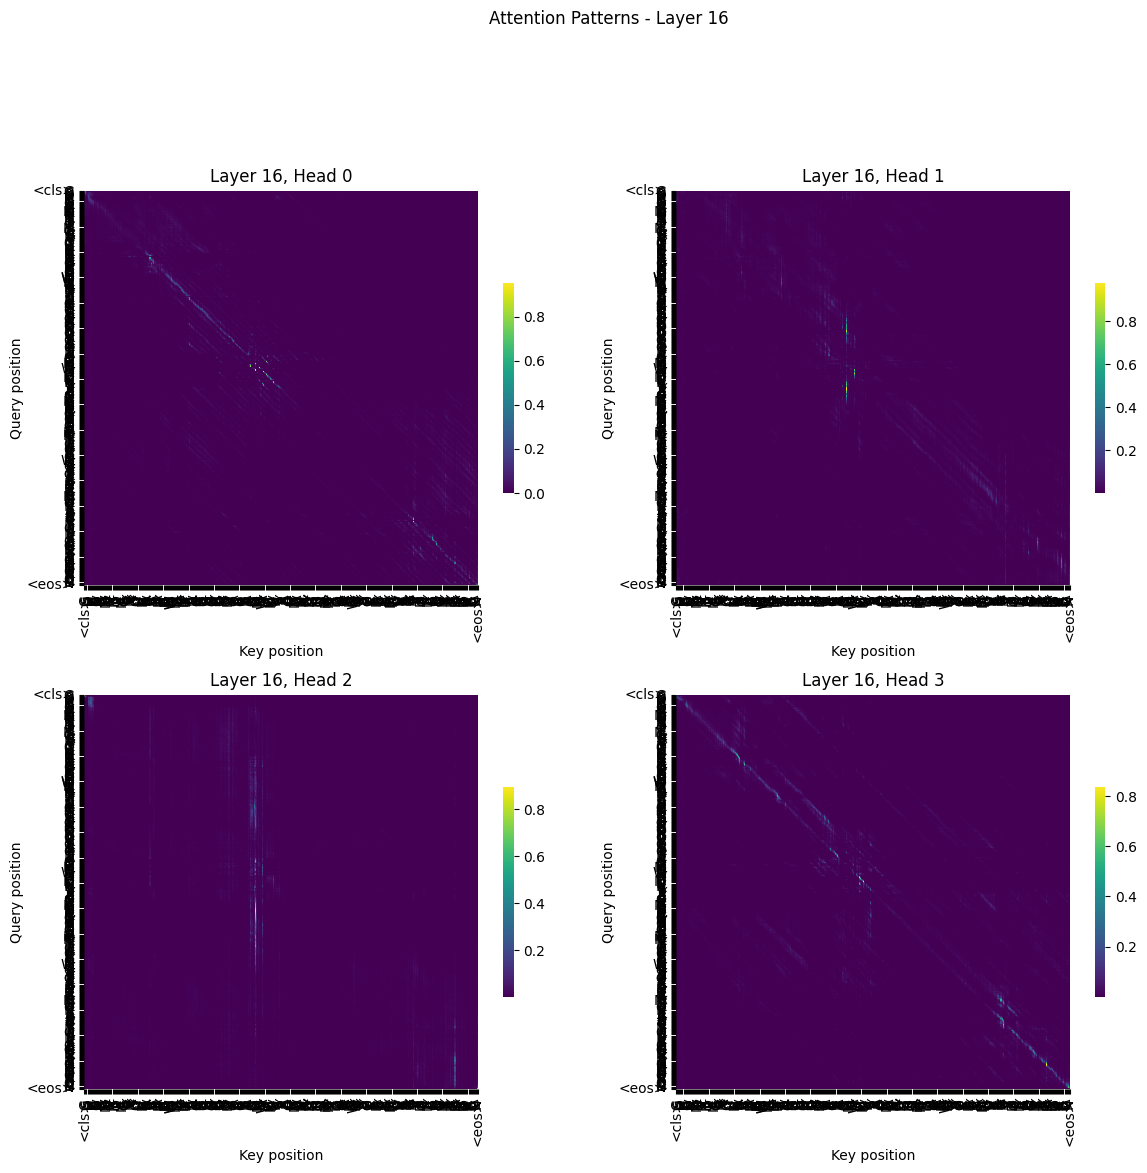

In [11]:
attn_weights_BHLL = attn_out_16_BLD_BHLL[1]  # Shape: (batch, heads, seq, seq)
n_heads = attn_weights_BHLL.shape[1]

# Plot first 4 heads
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for i, ax in enumerate(axes.flat):
    if i < n_heads:
        plot_attention_head(attn_weights_BHLL, layer_idx=16, head_idx=i,
                            tokens_BL=inputs_BL['input_ids'], ax=ax)
plt.suptitle('Attention Patterns - Layer 16', y=1.02)
plt.show()

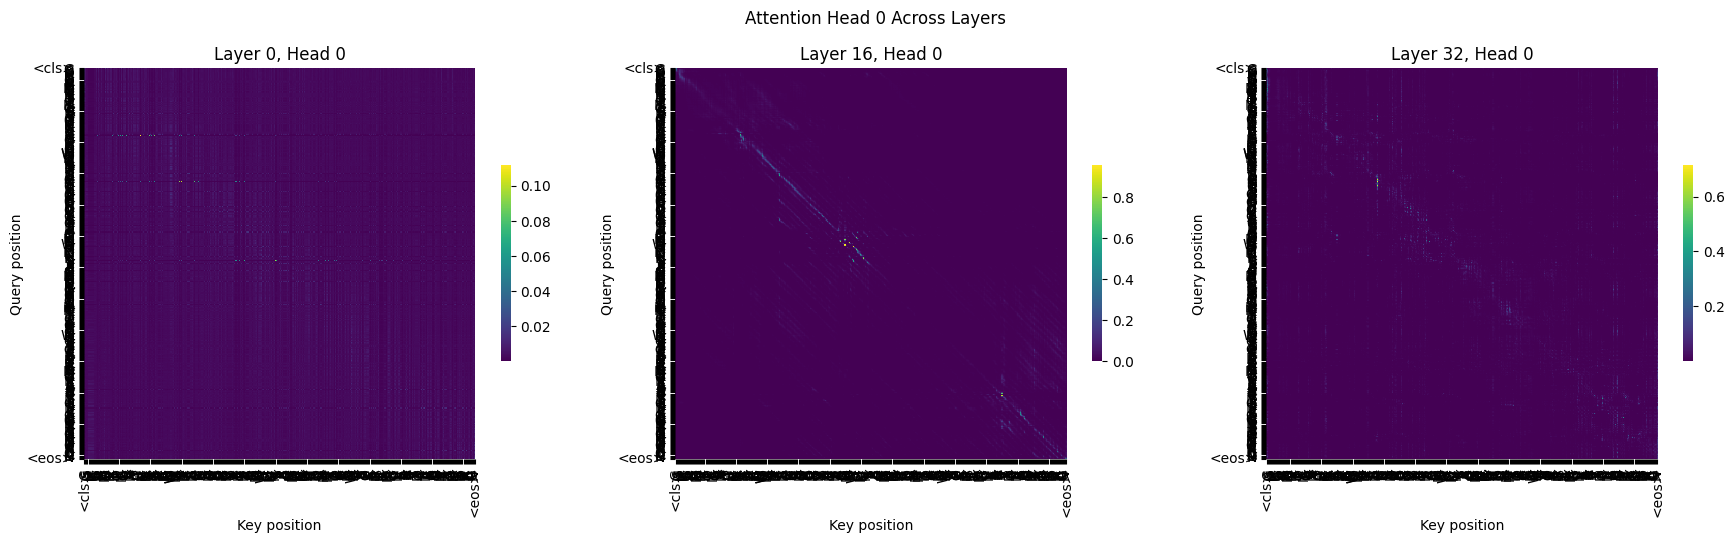

In [12]:
# Compare attention across layers (head 0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (layer_idx, attn_out) in zip(axes, [
    (0, attn_out_0_BLD_BHLL), (16, attn_out_16_BLD_BHLL), (32, attn_out_32_BLD_BHLL)
]):
    if isinstance(attn_out, tuple) and len(attn_out) > 1:
        plot_attention_head(attn_out[1], layer_idx=layer_idx, head_idx=0,
                          tokens_BL=inputs_BL['input_ids'], ax=ax)

plt.suptitle('Attention Head 0 Across Layers', y=1.02)
plt.tight_layout()
plt.show()

#### What do these show? 

[WIP] But feel free to try and interpret yourself ! 

In [13]:
# Memory cleanup before SAE section
del attn_out_0_BLD_BHLL, attn_out_16_BLD_BHLL, attn_out_32_BLD_BHLL
del attn_weights_BHLL
del normal_output, normal_logits_BLV, layer_16_out_BLD, logits_BLV

clear_memory()
log_memory("after attention cleanup")

[Memory - after attention cleanup] Allocated: 4.59 GB, Reserved: 4.83 GB


# 4 Sparse Autoencoders

Sparse Autoencoders (SAEs) learn to decompose neural network activations into sparse, interpretable features. We support two SAE backends:

| Backend | Source | Best For | Available Layers |
|---------|--------|----------|------------------|
| **InterProt** | [Adams et al.](https://github.com/etowahadams/interprot) | ESM2-650M | 4, 8, 12, 16, 20, 24, 28, 32 |
| **InterPLM** | [Simon et al.](https://interplm.ai/) | ESM2-8M | 1, 2, 3, 4, 5, 6 |

**SAE architecture:**
- **Encoder**: hidden_state → sparse latent (with top-k sparsity)
- **Decoder**: sparse latent → reconstructed hidden_state

**Key insight**: If an SAE reconstructs well (low error) while being sparse, the latent dimensions may correspond to interpretable features the model uses internally.

In [14]:
# Unified SAE loader - select the right backend for your model
from helpers.utils import load_sae, get_sae_info

# Check what SAEs are available for different models
print("SAE info for ESM2-650M:")
print(get_sae_info("650m"))
print("\nSAE info for ESM2-8M:")
print(get_sae_info("8m"))

SAE info for ESM2-650M:
{'model': 'esm2-650m', 'default_backend': 'interprot', 'esm_dim': 1280, 'num_layers': 33, 'interplm_layers': [1, 9, 18, 24, 30, 33], 'interprot_layers': [4, 8, 12, 16, 20, 24, 28, 32]}

SAE info for ESM2-8M:
{'model': 'esm2-8m', 'default_backend': 'interplm', 'esm_dim': 320, 'num_layers': 6, 'interplm_layers': [1, 2, 3, 4, 5, 6], 'interprot_layers': []}


In [15]:
# Load SAE for the current model (ESM2-650M) at layer 24
# The unified load_sae() function auto-selects the best backend:
#   - 650M: InterProt (default) or InterPLM 
#   - 8M: InterPLM (only option)

LAYER_IDX = 24

# Option 1: Auto-detect backend (recommended)
sae = load_sae(model_name="650m", layer=LAYER_IDX, device=device)

# Option 2: Explicitly specify backend (e.g., to use InterPLM for 650M)
# sae = load_sae("650m", layer=24, backend="interplm")

# Option 3: For 8M model (would need to reload ESM model first)
# sae = load_sae("8m", layer=3)

print(f"Loaded SAE for layer {LAYER_IDX}")
print(f"  Input dim (d_model): {sae.d_model}")
print(f"  Hidden dim (d_hidden): {sae.d_hidden}")
print(f"  Top-k sparsity: {sae.k}")
log_memory("after SAE load")

Loaded SAE for layer 24
  Input dim (d_model): 1280
  Hidden dim (d_hidden): 4096
  Top-k sparsity: 128
[Memory - after SAE load] Allocated: 4.63 GB, Reserved: 4.87 GB


## 4.1 Running the SAE Forward Pass

Let's extract activations and run them through the SAE. Note we exclude special tokens (`<cls>`, `<eos>`) since the SAE was trained only on amino acid positions.

In [16]:
# Get layer activations using NNsight trace
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the hidden states from layer 24
        # ESM layers return (hidden_states, attention_weights) tuple
        layer_hidden_BLD = model.esm.encoder.layer[LAYER_IDX].nns_output.save()

print(f"Layer {LAYER_IDX} hidden states shape: {layer_hidden_BLD.shape}")

Layer 24 hidden states shape: torch.Size([1, 379, 1280])


In [17]:
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get layer hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output # we do LAYER_IDX-1 because of how Adams et al. indexed the layers 

        # Extract AA tokens only (exclude special tokens)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # Call SAE inside the trace (ad-hoc module call)
        # This runs the SAE on the live tensor during inference
        sae_output_BAD = sae.forward_val(aa_hidden_BAD).save()

        # Also save original AA hidden for comparison
        original_aa_hidden_BAD = aa_hidden_BAD.save()

print(f"Original AA hidden shape: {original_aa_hidden_BAD.shape}")
print(f"SAE output shape: {sae_output_BAD.shape}")

Original AA hidden shape: torch.Size([1, 377, 1280])
SAE output shape: torch.Size([1, 377, 1280])


## 4.2 SAE Reconstruction Quality

Let's test how well the SAE reconstructs activations by comparing model outputs with and without the SAE in the loop.

In [54]:
# First, get baseline logits (no intervention) for comparison
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        baseline_logits_BLV = model.lm_head.output.save()

print(f"Baseline logits shape: {baseline_logits_BLV.shape}")

Baseline logits shape: torch.Size([1, 379, 33])


In [19]:
# Now, sae intervention: replace layer output with SAE reconstruction
# Here, we only modify AA positions, keep special tokens unchanged
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the layer's hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output

        # Extract AA tokens only (exclude <cls> at 0 and <eos> at -1)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # Compute SAE reconstruction on AA tokens only
        sae_recon_aa_BAD = sae.forward_val(aa_hidden_BAD)

        # INTERVENTION: Replace only the AA positions with SAE reconstruction
        # Keep <cls> and <eos> unchanged
        model.esm.encoder.layer[LAYER_IDX-1].nns_output[:, 1:-1, :] = sae_recon_aa_BAD

        # Get logits after intervention
        sae_logits_BLV = model.lm_head.output.save()

print(f"Intervened logits shape: {sae_logits_BLV.shape}")

Intervened logits shape: torch.Size([1, 379, 33])


In [20]:
# Compare baseline vs intervened predictions
def top_k_tokens(logits_BLV, tokenizer, k=5):
    """Get top-k predicted tokens for each position."""
    probs_BLV = torch.softmax(logits_BLV, dim=-1)
    top_probs_BLK, top_ids_BLK = probs_BLV.topk(k, dim=-1)
    return top_ids_BLK, top_probs_BLK

baseline_top_BLK, baseline_probs_BLK = top_k_tokens(baseline_logits_BLV[0], tokenizer)
sae_top_BLK, sae_probs_BLK = top_k_tokens(sae_logits_BLV[0], tokenizer)

# Check if top predictions match
top1_match = (baseline_top_BLK[:, 0] == sae_top_BLK[:, 0]).float().mean().item()
print(f"Top-1 prediction match rate: {top1_match:.1%}")

# Logit difference
logit_diff = (baseline_logits_BLV - sae_logits_BLV).abs().mean().item()
print(f"Mean absolute logit difference: {logit_diff:.4f}")

# KL divergence between distributions
baseline_log_probs_BLV = torch.log_softmax(baseline_logits_BLV, dim=-1)
sae_probs_full_BLV = torch.softmax(sae_logits_BLV, dim=-1)
kl_div = (sae_probs_full_BLV * (torch.log_softmax(sae_logits_BLV, dim=-1) - baseline_log_probs_BLV)).sum(dim=-1).mean().item()
print(f"KL divergence (sae || baseline): {kl_div:.4f}")


Top-1 prediction match rate: 95.0%
Mean absolute logit difference: 1.0963
KL divergence (sae || baseline): 0.5577


In [21]:
# Cleanup intermediate tensors
del layer_hidden_BLD, sae_output_BAD, original_aa_hidden_BAD
clear_memory()
log_memory("after SAE forward cleanup")

[Memory - after SAE forward cleanup] Allocated: 9.96 GB, Reserved: 10.66 GB


## 4.3 Intervening on SAE Latents

We can modify specific latent dimensions and observe the effect on model behavior. Here's a toy example that zeros out all latents (a destructive intervention that should hurt performance).

In [22]:

with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the layer's hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output

        # Extract AA tokens only (exclude <cls> at 0 and <eos> at -1)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # SAE recreating encoder forward 
        x, mu_F, std_F = sae.LN(aa_hidden_BAD)
        f_BAS = (x - sae.b_pre) @ sae.w_enc + sae.b_enc

        # toy intervention: set all latents to 0
        f_BAS[:, :, :] = 0

        topk_BAS = sae.topK_activation(f_BAS, sae.k)

        sae_recon_aa_BAD = (topk_BAS @ sae.w_dec + sae.b_pre) * std_F + mu_F

        # INTERVENTION: Replace only the AA positions with SAE reconstruction
        # Keep <cls> and <eos> unchanged
        model.esm.encoder.layer[LAYER_IDX-1].nns_output[:, 1:-1, :] = sae_recon_aa_BAD

        # Get logits after intervention
        intervened_logits_BLV = model.lm_head.output.save()

print(f"Intervened logits shape: {intervened_logits_BLV.shape}")

Intervened logits shape: torch.Size([1, 379, 33])


In [23]:
# Compare baseline vs intervened predictions
def top_k_tokens(logits_BLV, tokenizer, k=5):
    """Get top-k predicted tokens for each position."""
    probs_BLV = torch.softmax(logits_BLV, dim=-1)
    top_probs_BLK, top_ids_BLK = probs_BLV.topk(k, dim=-1)
    return top_ids_BLK, top_probs_BLK

baseline_top_BLK, baseline_probs_BLK = top_k_tokens(baseline_logits_BLV[0], tokenizer)
interv_top_BLK, interv_probs_BLK = top_k_tokens(intervened_logits_BLV[0], tokenizer)

# Check if top predictions match
top1_match = (baseline_top_BLK[:, 0] == interv_top_BLK[:, 0]).float().mean().item()
print(f"Top-1 prediction match rate: {top1_match:.1%}")

# Logit difference
logit_diff = (baseline_logits_BLV - intervened_logits_BLV).abs().mean().item()
print(f"Mean absolute logit difference: {logit_diff:.4f}")

# KL divergence between distributions
baseline_log_probs_BLV = torch.log_softmax(baseline_logits_BLV, dim=-1)
interv_probs_full_BLV = torch.softmax(intervened_logits_BLV, dim=-1)
kl_div = (interv_probs_full_BLV * (torch.log_softmax(intervened_logits_BLV, dim=-1) - baseline_log_probs_BLV)).sum(dim=-1).mean().item()
print(f"KL divergence (intervened || baseline): {kl_div:.4f}")


Top-1 prediction match rate: 7.7%
Mean absolute logit difference: 3.3827
KL divergence (intervened || baseline): 4.9162


In [24]:
# Cleanup before Section 5
del intervened_logits_BLV, interv_probs_full_BLV, baseline_log_probs_BLV
clear_memory()
log_memory("before Section 5")

[Memory - before Section 5] Allocated: 11.93 GB, Reserved: 12.65 GB


# 5 3D visualization of causally relevant latents

Now let's visualize SAE latent activations directly on the 3D protein structure. This helps identify which structural regions are associated with specific SAE features.

In [25]:
# Get SAE latent activations for visualization
with torch.no_grad():
    with model.trace() as tracer:
        with tracer.invoke(**inputs_BL):
            hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output
            aa_hidden_BAD = hidden_BLD[:, 1:-1, :]
            
            # Get SAE latent activations (before top-k)
            x, mu_F, std_F = sae.LN(aa_hidden_BAD)
            latent_activations_BAF = ((x - sae.b_pre) @ sae.w_enc + sae.b_enc).save()

# Move to CPU to free GPU memory
latent_activations_AF = latent_activations_BAF[0].cpu()
del latent_activations_BAF
clear_memory()

print(f"Latent activations shape: {latent_activations_AF.shape}")  # (377 AA, 4096 latents)
log_memory("after getting latent activations")

Latent activations shape: torch.Size([377, 4096])
[Memory - after getting latent activations] Allocated: 11.93 GB, Reserved: 12.65 GB


## 5.1 Finding Causally Important Latents

We use **zero-ablation** to find latents that causally affect predictions at specific structural regions. For each latent, we zero it out and measure how much the logits change at our target positions (two beta strands at positions 182 and 316).

In [26]:
# Define target positions: two beta strands in MetXA
WINDOW = 5
beta_strand_centers = {"strand_1": 182, "strand_2": 316}

beta_strand_indices = []
for name, center in beta_strand_centers.items():
    indices = list(range(center - WINDOW - 1, center + WINDOW))  # 0-indexed
    beta_strand_indices.extend(indices)
    seq = sequence_S[center - WINDOW - 1:center + WINDOW]
    print(f"{name} (pos {center-WINDOW}-{center+WINDOW-1}): {seq}")

beta_token_indices = [i + 1 for i in beta_strand_indices]  # +1 for <cls> token
print(f"\nTarget: {len(beta_strand_indices)} residues across 2 beta strands")

strand_1 (pos 177-186): DFMDNIVNLCS
strand_2 (pos 311-320): IKARYTLVSVT

Target: 22 residues across 2 beta strands


In [ ]:
# Zero-ablation study: find causally important latents
from tqdm import tqdm
import pandas as pd

n_latents = sae.d_hidden

# VRAM limit: Set based on your GPU memory
# - Colab free (15GB): You should be able to run all 4096 latents, but it takes ~15mins, so feel free to increase/decrease this number
# - 24GB+ GPU: can run all 4096 in about 5-8mins
MAX_LATENTS = 1000  

ablation_results = []
test_range = min(MAX_LATENTS, n_latents)

log_memory("before ablation loop")
print(f"Testing {test_range}/{n_latents} latents (set MAX_LATENTS=4096 for full search)")

for latent_idx in tqdm(range(test_range)):
    with torch.no_grad():
        with model.trace() as tracer:
            with tracer.invoke(**inputs_BL):
                hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output
                aa_hidden_BAD = hidden_BLD[:, 1:-1, :]
                
                # SAE encode → zero-ablate → decode
                x, mu_F, std_F = sae.LN(aa_hidden_BAD)
                f_BAS = (x - sae.b_pre) @ sae.w_enc + sae.b_enc
                f_BAS[:, :, latent_idx] = 0
                topk_BAS = sae.topK_activation(f_BAS, sae.k)
                sae_recon = (topk_BAS @ sae.w_dec + sae.b_pre) * std_F + mu_F
                
                model.esm.encoder.layer[LAYER_IDX-1].nns_output[:, 1:-1, :] = sae_recon
                ablated_logits = model.lm_head.output.save()
        
        logit_diff = (baseline_logits_BLV[0, beta_token_indices, :] - 
                      ablated_logits[0, beta_token_indices, :]).abs().mean().item()
        ablation_results.append({'latent_idx': latent_idx, 'logit_diff': logit_diff})
    
    # Clear cache periodically to prevent memory buildup
    if (latent_idx + 1) % 100 == 0:
        clear_memory()

clear_memory()
df = pd.DataFrame(ablation_results).sort_values('logit_diff', ascending=False)
log_memory("after ablation loop")
print("Done!")

[Memory - before ablation loop] Allocated: 10.54 GB, Reserved: 11.23 GB
Testing 4096/4096 latents (set MAX_LATENTS=4096 for full search)


100%|██████████| 4096/4096 [02:06<00:00, 32.48it/s]


[Memory - after ablation loop] Allocated: 10.54 GB, Reserved: 11.21 GB
Done!


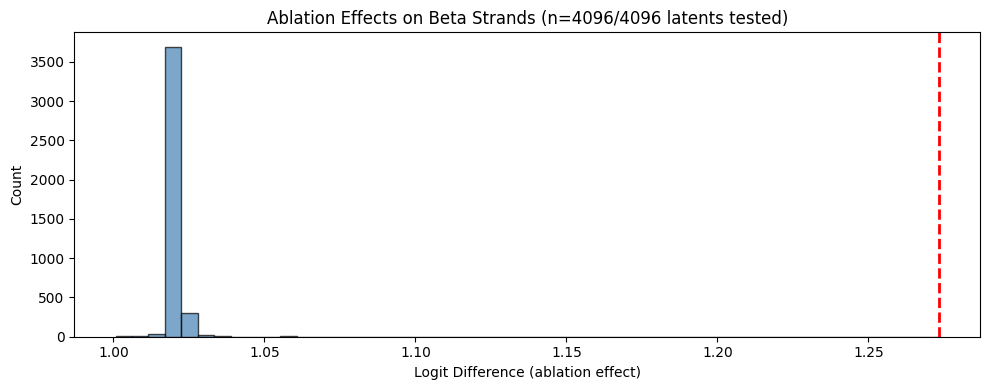


Top 10 latents by causal importance:
  Latent  976: logit_diff = 1.2733 ← selected
  Latent  110: logit_diff = 1.2369 
  Latent 3016: logit_diff = 1.1425 
  Latent 1300: logit_diff = 1.1195 
  Latent   53: logit_diff = 1.1051 
  Latent  967: logit_diff = 1.0894 
  Latent 1718: logit_diff = 1.0872 
  Latent 3867: logit_diff = 1.0822 
  Latent 2215: logit_diff = 1.0796 
  Latent 2631: logit_diff = 1.0683 


In [72]:
# Show top 10 causally important latents + distribution
selected_latent_idx = int(df.iloc[0]['latent_idx'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['logit_diff'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(df.iloc[0]['logit_diff'], color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Logit Difference (ablation effect)')
ax.set_ylabel('Count')
ax.set_title(f'Ablation Effects on Beta Strands (n={len(df)}/{n_latents} latents tested)')
plt.tight_layout()
plt.show()

print(f"\nTop 10 latents by causal importance:")
for i, row in df.head(10).iterrows():
    marker = "← selected" if int(row['latent_idx']) == selected_latent_idx else ""
    print(f"  Latent {int(row['latent_idx']):4d}: logit_diff = {row['logit_diff']:.4f} {marker}")

In [76]:
# Visualize the top latent on the 3D protein structure
from helpers.protein_viz_utils import (
    view_single_protein, show_colorbar, rwb_colormap_fn, 
    get_single_chain_afdb_structure
)

latent_values_A = latent_activations_AF[:, selected_latent_idx].detach().numpy().tolist()

# Align to AlphaFold structure (skip His-tag)
HIS_TAG_LEN = 19
af_structure = get_single_chain_afdb_structure("P45131")
af_residue_count = len(list(af_structure.get_residues()))
latent_values_for_af = latent_values_A[HIS_TAG_LEN:HIS_TAG_LEN + af_residue_count]
beta_strand_af_indices = [i - HIS_TAG_LEN for i in beta_strand_indices if i >= HIS_TAG_LEN]

# Only highlight the endpoints of each beta strand (cleaner visualization)
beta_strand_endpoints = [
    beta_strand_af_indices[0],   # strand_1 start
    beta_strand_af_indices[9],   # strand_1 end  
    beta_strand_af_indices[10],  # strand_2 start
    beta_strand_af_indices[19],  # strand_2 end
]

print(f"Latent {selected_latent_idx} activation on MetXA structure")
print(f"Red/Blue = activation strength, Black sticks = beta strand endpoints\n")

# Show colorbar first
show_colorbar(rwb_colormap_fn, min(latent_values_for_af), max(latent_values_for_af))

Latent 976 activation on MetXA structure
Red/Blue = activation strength, Black sticks = beta strand endpoints



In [77]:
# Then 3D structure
view = view_single_protein(
    uniprot_id="P45131",
    values_to_color=latent_values_for_af,
    colormap_fn=rwb_colormap_fn,
    residues_to_highlight=beta_strand_endpoints,
    highlight_color="black",
    default_color="white",
    pymol_params={"width": 800, "height": 500}
)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The black, "3 letter" locations are the amino acids / tokens at the ends of the beta strands we focused on. 
This seems to be activating the most on the beta sheet (the group of long flat lines) and the also the alpha helix (spirals) around them.

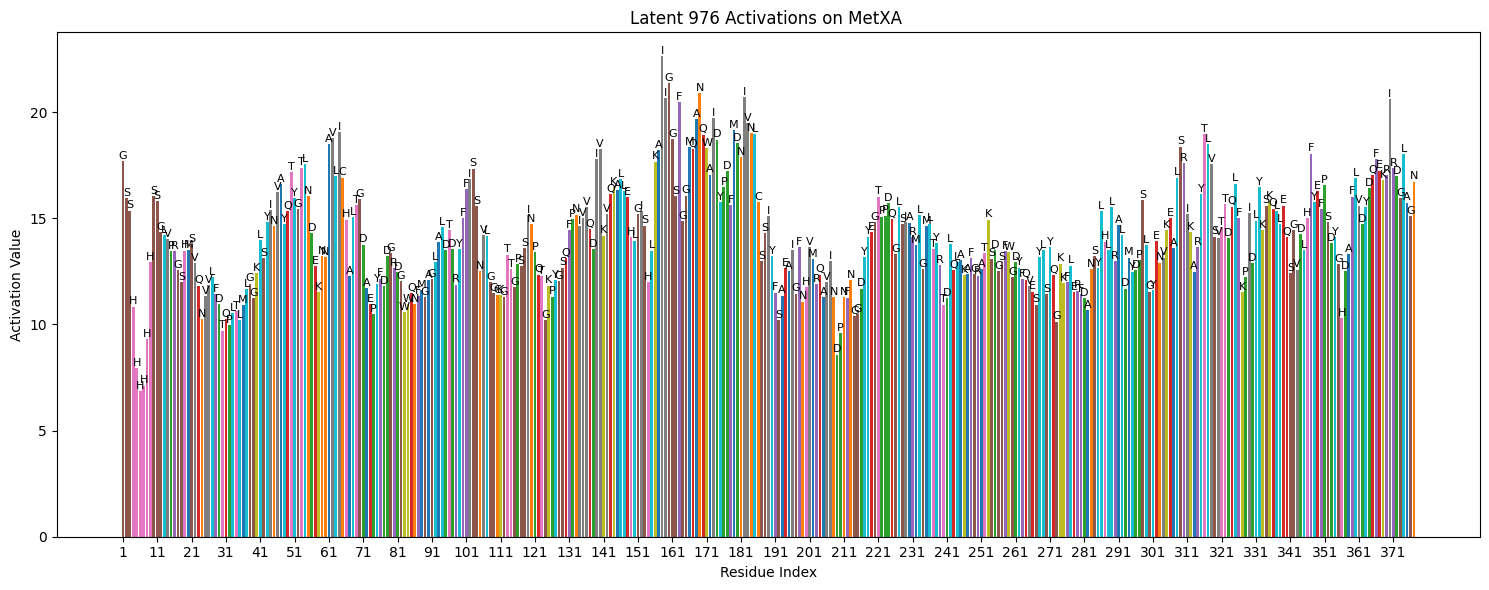

In [75]:
# Sequence-position bar plot view
from helpers.protein_viz_utils import vizualize_latent_on_protein

vizualize_latent_on_protein(
    sequence=sequence_S,
    activations=latent_activations_AF.detach().numpy(),
    latent_idx=selected_latent_idx,
    seq_name="MetXA",
    path="./plots",
    save=False
)

This type of broad causal intervention will lead to finding latents that active across the entire sequence. We will cover finding circuits for specific tasks later on, but this should give a good idea of the pipeline. 

## 5.3 Latent Interp

This is going to be updated soon! But you can explore the latents in the respective SAE UIs.

For a given layer and latent index, access the feature dashboard for interprot like this: https://interprot.com/#/sae-viz/SAE4096-L{layer_idx}/{latent_idx}

Example: https://interprot.com/#/sae-viz/SAE4096-L24/976

and for interplm, go to https://interplm.ai/ and enter the layer and feature index on the left bar. 


## 6. Next Steps: pLM Circuits

This section will cover more advanced techniques for mechanistic interpretability of protein language models.

**Coming soon:**
- Activation patching and attribution patching
- Finding causally important latents for contact prediction

For now, see the [plm_circuits repository](https://github.com/NainaniJatinZ/plm_circuits/) for the original implementation.


NNsight makes interpretability workflows much cleaner than raw PyTorch hooks. The patterns here generalize to other transformer models—just watch for naming conflicts (like `.output`) and model-specific quirks.

**Questions or issues?** Open an issue on [GitHub](https://github.com/NainaniJatinZ/plm_nnsight) or reach out on Twitter/X [zephyr_wade](https://x.com/zephyr_wade).

---

*Tutorial by [Jatin Nainani](https://nainanijatinz.github.io/). Built with [NNsight](https://nnsight.net/).* 